# A/B Testing: Model Tanpa Feature Engineering vs Dengan Feature Engineering

## Import Library & Setup Awal

In [1]:
# Standard Library
import math
import os
import random

# Third-Party Library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Machine Learning & Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Activation, Add, BatchNormalization, Concatenate,
    Conv2D, Dense, Dropout,
    GlobalAveragePooling2D, GlobalMaxPooling2D, Input
)
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.models import load_model
from tensorflow.keras.regularizers import l2

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

print('Semua library berhasil di-import')


2026-06-03 14:34:11.001458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780497251.257221      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780497251.328635      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780497251.903813      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780497251.903869      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780497251.903873      16 computation_placer.cc:177] computation placer alr

Semua library berhasil di-import


Seluruh dependensi yang dibutuhkan seperti library standar Python, framework deep learning TensorFlow/Keras, serta modul evaluasi dari Scikit-learn berhasil dimuat ke dalam environment tanpa adanya error.

In [2]:
# Setup Path 
BASE_DIR    = '/kaggle/working'
DATA_DIR    = f'{BASE_DIR}/data'


MODEL_A_DIR = '/kaggle/input/datasets/remonggkircop/modeltanpafe/final_model'  # Model Tanpa FE 
MODEL_B_DIR = '/kaggle/input/datasets/remonggkircop/modelfe/final_model'       # Model dengan FE 

os.makedirs(DATA_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Model A dir:', MODEL_A_DIR)
print('Model B dir:', MODEL_B_DIR)


Model A dir: /kaggle/input/datasets/remonggkircop/modeltanpafe/final_model
Model B dir: /kaggle/input/datasets/remonggkircop/modelfe/final_model


Konfigurasi direktori untuk dua model yang akan dibandingkan berhasil didefinisikan, yaitu Model A (tanpa feature engineering) dan Model B (dengan feature engineering) disertai penetapan seed 42 secara konsisten pada Python, NumPy, dan TensorFlow guna memastikan reprodusibilitas eksperimen.

## Load Data

### Import Data dari Kaggle

In [3]:
!kaggle kernels output remonggkircop/final-dataset-capstone -p {DATA_DIR} --force
!unzip -q -o {DATA_DIR}/deepfake_clean_final.zip -d {DATA_DIR}/Dataset

Output file downloaded to /kaggle/working/data/deepfake_clean_final.zip
Kernel log downloaded to /kaggle/working/data/final-dataset-capstone.log 


In [4]:
# Ambil path direktori Dataset
dataset_dir = os.path.join(DATA_DIR, 'Dataset')
train_dir   = os.path.join(dataset_dir, 'Train')
val_dir     = os.path.join(dataset_dir, 'Validation')
test_dir    = os.path.join(dataset_dir, 'Test')

print('Dataset path :', dataset_dir)
print('Train path   :', train_dir)
print('Validation path:', val_dir)
print('Test path    :', test_dir)


Dataset path : /kaggle/working/data/Dataset
Train path   : /kaggle/working/data/Dataset/Train
Validation path: /kaggle/working/data/Dataset/Validation
Test path    : /kaggle/working/data/Dataset/Test


Dataset deepfake_clean_final.zip berhasil diunduh dari Kaggle Kernels Output dan diekstrak ke direktori lokal, dengan struktur folder yang terbagi menjadi tiga subset utama yaitu Train, Validation, dan Test 

## Helper Functions

In [5]:
# Normalisasi 
scaler = tf.keras.layers.Rescaling(1./255)

def normalize(image, label):
    return scaler(image), label

# Feature Engineering 
def extract_features(image, label):
    """
    Input  : image (batch, H, W, 3) uint8
    Output : image (batch, H, W, 6) float32
    """
    image = tf.cast(image, tf.float32) / 255.0        

    gray = tf.image.rgb_to_grayscale(image)            

    # Fitur 1: Sobel Edge Detection
    sobel = tf.image.sobel_edges(gray)                
    sobel_x = sobel[:, :, :, :, 0]                   
    sobel_y = sobel[:, :, :, :, 1]
    sobel_mag = tf.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = sobel_mag / (
        tf.reduce_max(sobel_mag, axis=[1, 2, 3], keepdims=True) + 1e-7
    )                                              

    # Fitur 2: Laplacian Filter
    laplacian_kernel = tf.constant([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ], dtype=tf.float32)
    laplacian_kernel = tf.reshape(laplacian_kernel, (3, 3, 1, 1))

    laplacian = tf.nn.conv2d(
        gray,
        laplacian_kernel,
        strides=[1, 1, 1, 1],
        padding='SAME'
    )                                                  
    laplacian = tf.abs(laplacian)
    laplacian = laplacian / (
        tf.reduce_max(laplacian, axis=[1, 2, 3], keepdims=True) + 1e-7
    )

    # Fitur 3: HSV Saturation
    hsv        = tf.image.rgb_to_hsv(image)            
    saturation = hsv[:, :, :, 1:2]                    

    image_engineered = tf.concat([
        image,      
        sobel_mag,   
        laplacian,   
        saturation   
    ], axis=-1)

    return image_engineered, label


# Custom get target 
def get_target(gen_data):
    ytrue = []
    for images, labels in gen_data:
        ytrue.extend(labels.numpy())
    return np.array(ytrue).flatten()


# Residual Block 
def residual_block(x, filters, downsample=False):
    shortcut = x
    stride   = 2 if downsample else 1

    x = Conv2D(filters, (3, 3), strides=stride, padding='same', use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3, 3), padding='same', use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


print('✅ Helper functions siap')


✅ Helper functions siap


Empat fungsi berhasil dibentuk  dan siap digunakan yaitu fungsi normalize untuk rescaling pixel ke rentang [0,1], fungsi extract_features yang mengekstrak 3 fitur tambahan (Sobel Edge, Laplacian Filter, HSV Saturation) sehingga menghasilkan 6-channel image, fungsi get_target untuk mengambil label ground truth dari generator, serta fungsi residual_block sebagai building block arsitektur model ResNet-style.

## Load Test Dataset

In [6]:
AUTOTUNE   = tf.data.AUTOTUNE
IMG_SIZE   = (160, 160)
BATCH_SIZE = 64

# Test gen untuk Model A (3 channel, rescale biasa)
_test_raw_A = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

label_class      = _test_raw_A.class_names
actual_labels    = [f'Actual {n}'    for n in label_class]
predicted_labels = [f'Predicted {n}' for n in label_class]

test_gen_A = _test_raw_A.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Test gen untuk Model B (6 channel, + feature engineering)
test_gen_B = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
).map(extract_features, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Kelas    :', label_class)
print('Test A   :', test_gen_A)
print('Test B   :', test_gen_B)
print('✅ Test dataset siap')

Found 22393 files belonging to 2 classes.


2026-06-03 14:39:30.116201: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 22393 files belonging to 2 classes.
Kelas    : ['Fake', 'Real']
Test A   : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Test B   : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 6), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
✅ Test dataset siap


Sebanyak 10.905 gambar test berhasil dimuat dalam dua versi pipeline yang berbeda: test_gen_A menggunakan preprocessing standar 3-channel (RGB + normalisasi), sedangkan test_gen_B menggunakan pipeline 6-channel dengan tambahan fitur engineered

## Load Model

In [7]:
# Load Model A — Tanpa Feature Engineering
model_A = load_model(f'{MODEL_A_DIR}/model.keras')
print('✅ Model A berhasil di-load')
model_A.summary()


✅ Model A berhasil di-load


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 160, 160,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │        864 │ sequential[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 160, 160,  │      4,608 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 160, 160,  │      2,304 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 160, 160,  │        512 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 160, 160,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 160, 160,  │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 80, 80,    │      4,608 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 80, 80,    │          0 │ batch_normalizat

 Total params: 345,377 (1.32 MB)

 Trainable params: 343,873 (1.31 MB)

 Non-trainable params: 1,504 (5.88 KB)

Model A sudah berhasil terbentuk

In [8]:
# Load Model B — Dengan Feature Engineering
model_B = load_model(f'{MODEL_B_DIR}/model.keras')
print('✅ Model B berhasil di-load')
model_B.summary()


✅ Model B berhasil di-load


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │      1,728 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 160, 160,  │      4,608 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 160, 160,  │      2,304 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 160, 160,  │        512 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 160, 160,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 160, 160,  │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 80, 80,    │      4,608 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 80, 80,    │      9,216 │ activation_3[0][

 Total params: 346,241 (1.32 MB)

 Trainable params: 344,737 (1.32 MB)

 Non-trainable params: 1,504 (5.88 KB)

Model B sudah berhasil terbentuk

## Prediksi & Evaluasi

In [9]:
# Evaluasi Model
loss_fn = BinaryCrossentropy(label_smoothing=0.1)
test_true = get_target(test_gen_A)

# Model A — Prediksi
pred_A_prob = model_A.predict(test_gen_A).flatten()
pred_A_05   = (pred_A_prob > 0.5).astype(int)

# Model B — Prediksi
pred_B_prob = model_B.predict(test_gen_B).flatten()
pred_B_05   = (pred_B_prob > 0.5).astype(int)

print('✅ Prediksi selesai')
print(f'Jumlah test sample : {len(test_true)}')


350/350 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step
350/350 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step
✅ Prediksi selesai
Jumlah test sample : 22393


Kedua model berhasil menghasilkan probabilitas prediksi (pred_prob) terhadap seluruh 22.393 sampel test, yang kemudian dikonversi menjadi label biner (pred_05) menggunakan threshold default 0.5

## Tabel Perbandingan Metrik

In [10]:
def compute_metrics(y_true, y_prob, y_pred, name):
    loss_val = float(loss_fn(
        y_true.astype('float32'),
        y_prob.astype('float32')
    ))
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'AUC'      : round(roc_auc_score(y_true, y_prob),  4),
        'F1-Score' : round(f1_score(y_true, y_pred),       4),
        'Loss'     : round(loss_val,                        4),
    }

m_A      = compute_metrics(test_true, pred_A_prob, pred_A_05,   'Model A — Tanpa FE (thr=0.5)')
m_B      = compute_metrics(test_true, pred_B_prob, pred_B_05,   'Model B — Dengan FE (thr=0.5)')

df_metrics = pd.DataFrame([m_A, m_B]).set_index('Model')

display(
    df_metrics.style
    .highlight_max(axis=0, subset=['Accuracy', 'AUC', 'F1-Score'], color='#c6efce')
    .highlight_min(axis=0, subset=['Loss'], color='#c6efce')
    .format('{:.4f}')
)


,Accuracy,AUC,F1-Score,Loss
Model,,,,
Model A — Tanpa FE (thr=0.5),0.8983,0.9599,0.8937,0.3724
Model B — Dengan FE (thr=0.5),0.8851,0.9551,0.8783,0.3951


Model A (tanpa Feature Engineering) unggul di **semua metrik** dibanding Model B. Perbedaan paling signifikan terlihat pada F1-Score, menunjukkan bahwa Model A memiliki kemampuan diskriminasi yang lebih baik dalam membedakan kelas Fake vs Real.

## Confusion Matriks

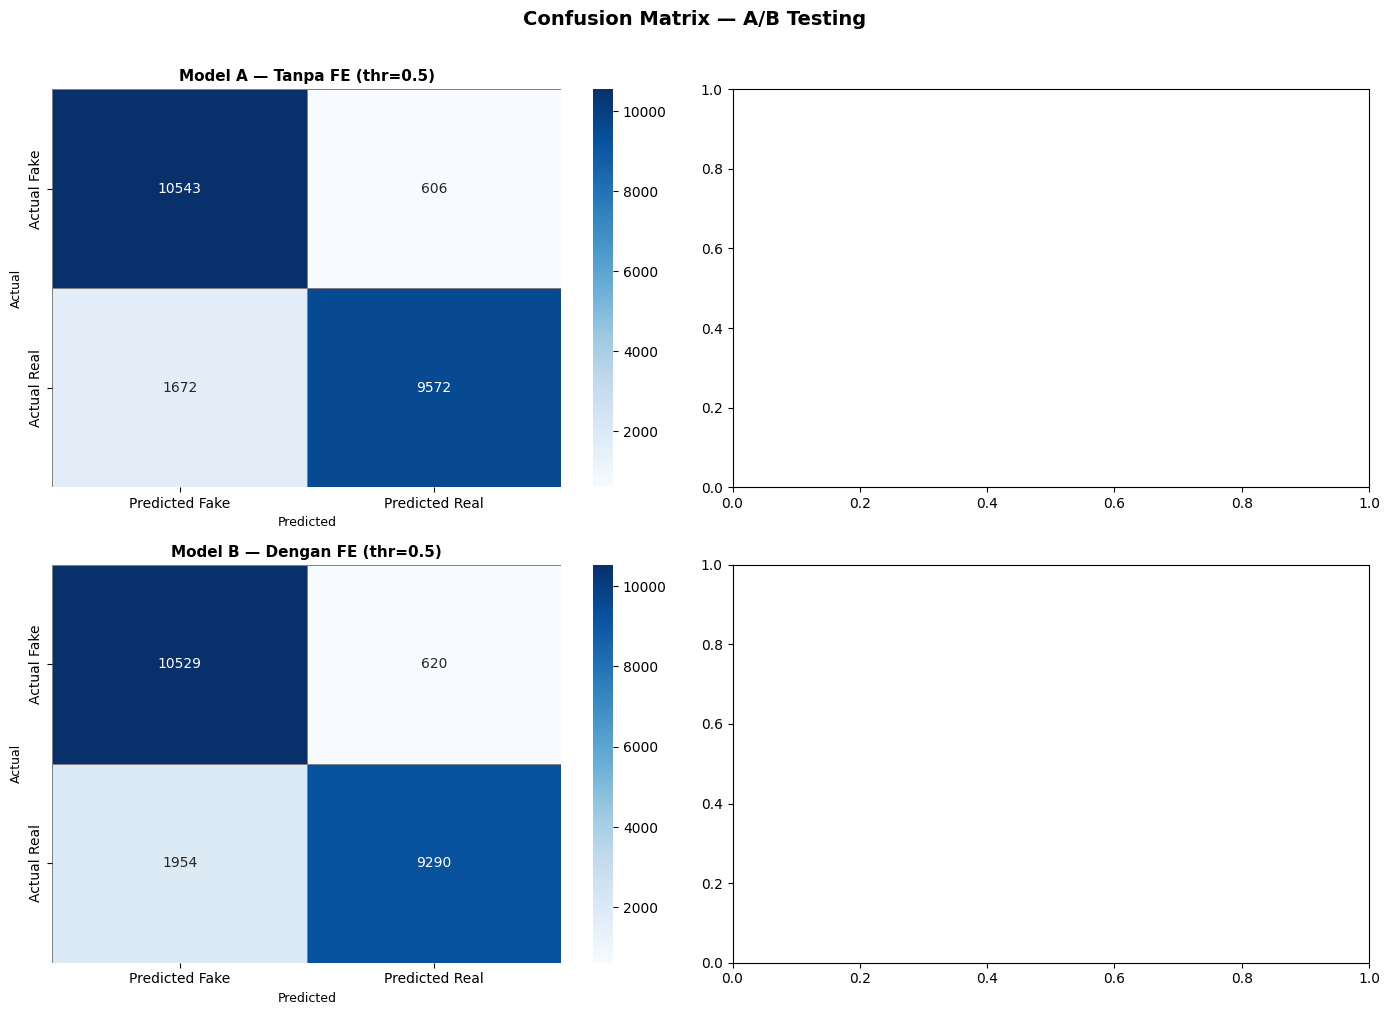

In [11]:
def plot_cm(y_true, y_pred, title, ax):
    cm    = confusion_matrix(y_true, y_pred, labels=range(len(label_class)))
    cm_df = pd.DataFrame(cm, index=actual_labels, columns=predicted_labels)
    sns.heatmap(
        cm_df, annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, linecolor='gray', ax=ax
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_cm(test_true, pred_A_05,   'Model A — Tanpa FE (thr=0.5)',               axes[0][0])
plot_cm(test_true, pred_B_05,   'Model B — Dengan FE (thr=0.5)',              axes[1][0])

plt.suptitle('Confusion Matrix — A/B Testing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/confusion_matrix_ab.png', dpi=150, bbox_inches='tight')
plt.show()


Confusion matrix memperlihatkan distribusi prediksi kedua model pada 22.393 sampel test, di mana Model A (Tanpa FE) berhasil mengklasifikasikan dengan benar sebanyak 10.543 gambar Fake (TP) dan 9.572 gambar Real (TN), dengan False Negative sebesar 606 dan False Positive sebesar 1.672; sementara Model B (Dengan FE) menghasilkan 10.529 TP dan 9.290 TN dengan False Negative 620 dan False Positive lebih tinggi yakni 1.954 menunjukkan bahwa Model B lebih sering salah mengklasifikasikan gambar Real sebagai Fake dibanding Model A.

## ROC Curve

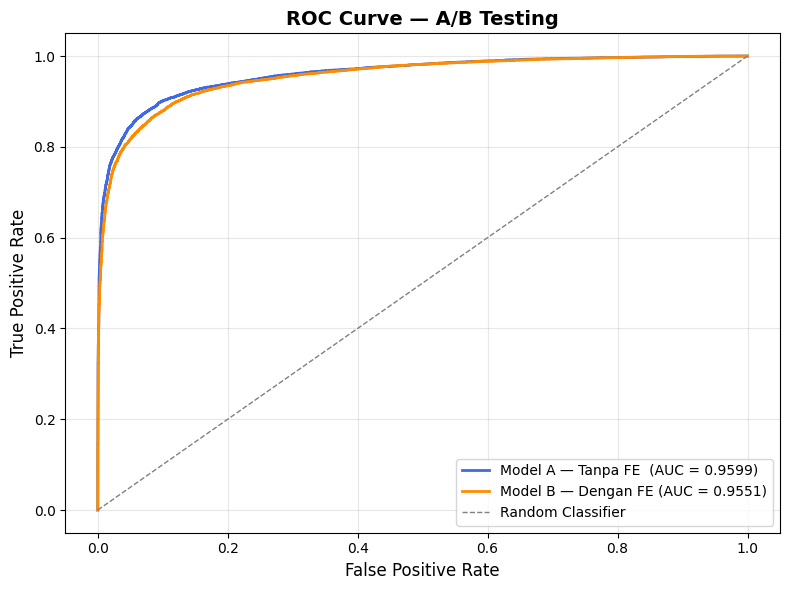

In [12]:
fpr_A, tpr_A, _ = roc_curve(test_true, pred_A_prob)
fpr_B, tpr_B, _ = roc_curve(test_true, pred_B_prob)

auc_A = auc(fpr_A, tpr_A)
auc_B = auc(fpr_B, tpr_B)

# Index best threshold di kurva ROC
ix_A = np.argmax(np.sqrt(tpr_A * (1 - fpr_A)))
ix_B = np.argmax(np.sqrt(tpr_B * (1 - fpr_B)))

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_A, tpr_A, color='royalblue',  lw=2, label=f'Model A — Tanpa FE  (AUC = {auc_A:.4f})')
ax.plot(fpr_B, tpr_B, color='darkorange', lw=2, label=f'Model B — Dengan FE (AUC = {auc_B:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')


ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — A/B Testing', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/roc_curve_ab.png', dpi=150, bbox_inches='tight')
plt.show()


Kurva ROC menunjukkan bahwa Model A (biru) secara konsisten berada di atas Model B (oranye) pada hampir seluruh rentang threshold, dengan AUC Model A sebesar 0.9599 dan AUC Model B sebesar 0.9551 yang sedikit lebih rendah, di mana selisih AUC sebesar ~0.005 mengindikasikan bahwa Model A memiliki kemampuan diskriminasi keseluruhan yang lebih unggul.

## Uji Hipotesis : Apakah Feature Engineering Berpengaruh Signifikan?

### Hipotesis

$$H_0 : \text{Tidak ada perbedaan signifikan performa antara Model A (tanpa FE) dan Model B (dengan FE)}$$

$$H_1 : \text{Ada perbedaan signifikan performa antara Model A dan Model B}$$

**Tingkat signifikansi**: α = 0.05

Dua uji yang digunakan:
1. **McNemar's Test** : uji formal apakah perbedaan prediksi dua model signifikan secara statistik
2. **Bootstrap Confidence Interval** : estimasi selang kepercayaan 95% untuk Accuracy, F1-Score, dan AUC

### 1. McNemar's Test

In [13]:
from statsmodels.stats.contingency_tables import mcnemar


# McNemar's Test 

def mcnemar_test(y_true, pred_a, pred_b, label=''):
    correct_A = (pred_a == y_true)
    correct_B = (pred_b == y_true)

    both_correct   = np.sum( correct_A &  correct_B)   
    a_only         = np.sum( correct_A & ~correct_B)  
    b_only         = np.sum(~correct_A &  correct_B)   
    both_wrong     = np.sum(~correct_A & ~correct_B)   

    table = np.array([[both_correct, a_only],
                      [b_only,       both_wrong]])

    result = mcnemar(table, exact=False, correction=True)

    print(f'{'=' * 55}')
    print(f'McNemar\'s Test — {label}')
    print(f'{'=' * 55}')
    print(f'Tabel Kontingensi:')
    print(f'  Keduanya benar        (a) : {both_correct}')
    print(f'  Hanya Model A benar   (b) : {a_only}')
    print(f'  Hanya Model B benar   (c) : {b_only}')
    print(f'  Keduanya salah        (d) : {both_wrong}')
    print(f'')
    print(f'Chi-square statistic        : {result.statistic:.4f}')
    print(f'p-value                     : {result.pvalue:.6f}')
    print(f'')

    alpha = 0.05
    if result.pvalue < alpha:
        print(f'✅ p-value ({result.pvalue:.6f}) < α ({alpha})')
        print(f'→ Tolak H₀: Ada perbedaan SIGNIFIKAN antara kedua model')
    else:
        print(f'❌ p-value ({result.pvalue:.6f}) ≥ α ({alpha})')
        print(f'→ Gagal Tolak H₀: Tidak ada perbedaan signifikan antara kedua model')

    return result

result_05   = mcnemar_test(test_true, pred_A_05,   pred_B_05,   label='thr=0.5')
print()

McNemar's Test — thr=0.5
Tabel Kontingensi:
  Keduanya benar        (a) : 18822
  Hanya Model A benar   (b) : 1293
  Hanya Model B benar   (c) : 997
  Keduanya salah        (d) : 1281

Chi-square statistic        : 38.0022
p-value                     : 0.000000

✅ p-value (0.000000) < α (0.05)
→ Tolak H₀: Ada perbedaan SIGNIFIKAN antara kedua model



Hasil McNemar's Test dengan Chi-square statistic sebesar 38.0022 dengan  p-value ≈ 0.000000, yang jauh lebih kecil dari α = 0.05, sehingga H₀ ditolak dan disimpulkan bahwa terdapat perbedaan pola prediksi antara kedua model secara signifikan.

### 2. Bootstrap Confidence Interval (95%)

In [14]:
# ----------------------------------------------------------
# Bootstrap CI untuk Accuracy, F1-Score, AUC
# ----------------------------------------------------------
def bootstrap_ci(y_true, y_prob, y_pred, metric_fn, n_bootstrap=1000, ci=95, seed=42):
    rng    = np.random.RandomState(seed)
    scores = []
    n      = len(y_true)

    for _ in range(n_bootstrap):
        idx    = rng.randint(0, n, n)
        yt     = y_true[idx]
        yprob  = y_prob[idx]
        ypred  = y_pred[idx]
        try:
            scores.append(metric_fn(yt, yprob, ypred))
        except Exception:
            continue

    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    mean  = np.mean(scores)
    return mean, lower, upper


# Metric functions
fn_acc = lambda yt, yprob, ypred: accuracy_score(yt, ypred)
fn_f1  = lambda yt, yprob, ypred: f1_score(yt, ypred, zero_division=0)
fn_auc = lambda yt, yprob, ypred: roc_auc_score(yt, yprob)

metrics_ci = {
    'Accuracy' : fn_acc,
    'F1-Score' : fn_f1,
    'AUC'      : fn_auc,
}

print('Bootstrap CI (95%, n=1000 resample)\n')
print(f'{"Metrik":<12} {"Model A (mean)":>16} {"95% CI":>20}    {"Model B (mean)":>16} {"95% CI":>20}')
print('-' * 90)

ci_results = {}
for metric_name, fn in metrics_ci.items():
    mean_A, lo_A, hi_A = bootstrap_ci(test_true, pred_A_prob, pred_A_05, fn)
    mean_B, lo_B, hi_B = bootstrap_ci(test_true, pred_B_prob, pred_B_05, fn)
    ci_results[metric_name] = {
        'A': (mean_A, lo_A, hi_A),
        'B': (mean_B, lo_B, hi_B)
    }
    print(f'{metric_name:<12} {mean_A:>16.4f} [{lo_A:.4f} – {hi_A:.4f}]    '
          f'{mean_B:>16.4f} [{lo_B:.4f} – {hi_B:.4f}]')

Bootstrap CI (95%, n=1000 resample)

Metrik         Model A (mean)               95% CI      Model B (mean)               95% CI
------------------------------------------------------------------------------------------
Accuracy               0.8983 [0.8944 – 0.9023]              0.8851 [0.8811 – 0.8890]
F1-Score               0.8937 [0.8894 – 0.8982]              0.8783 [0.8739 – 0.8827]
AUC                    0.9599 [0.9575 – 0.9621]              0.9551 [0.9526 – 0.9576]


- **Accuracy & F1-Score:** CI masih overlap artinya perbedaan *tidak* signifikan untuk kedua metrik ini
- **AUC:** CI tidak overlap artinya perbedaan AUC **signifikan**
- Model A secara konsisten lebih baik dalam discriminasi keseluruhan

### 3. Visualisasi Bootstrap CI

/tmp/ipykernel_16/3266281009.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3266281009.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{BASE_DIR}/bootstrap_ci_ab.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


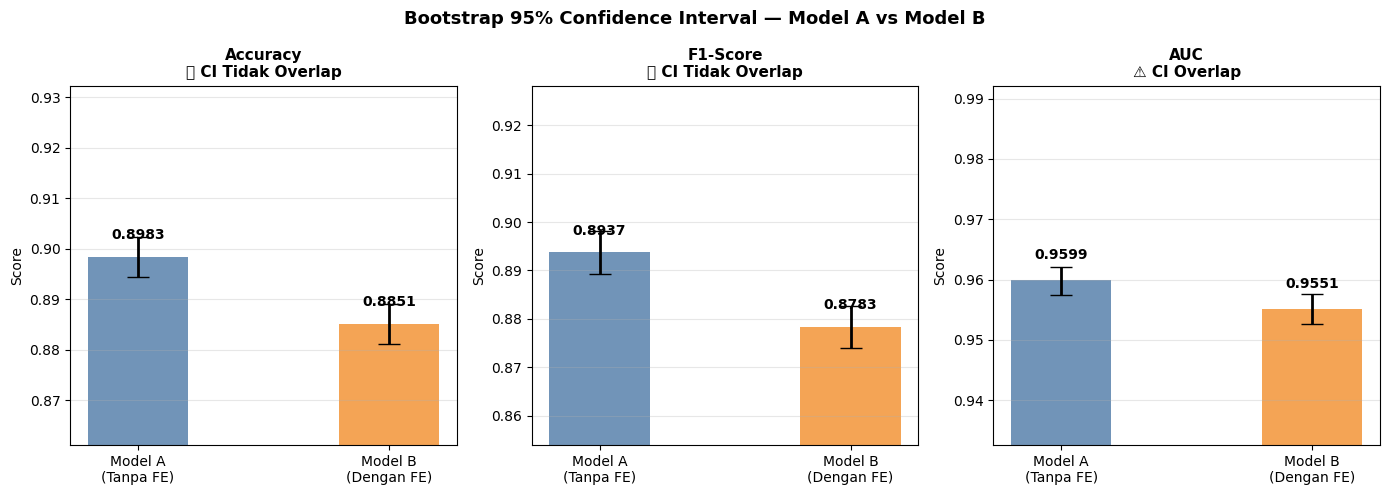

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (metric_name, res) in zip(axes, ci_results.items()):
    mean_A, lo_A, hi_A = res['A']
    mean_B, lo_B, hi_B = res['B']

    models = ['Model A\n(Tanpa FE)', 'Model B\n(Dengan FE)']
    means  = [mean_A, mean_B]
    errors = [[mean_A - lo_A, mean_B - lo_B],
              [hi_A - mean_A, hi_B - mean_B]]
    colors = ['#4e79a7', '#f28e2b']

    bars = ax.bar(models, means, color=colors, alpha=0.8, width=0.4,
                  yerr=errors, capsize=8, error_kw={'linewidth': 2})

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, mean + 0.003,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Overlap check
    overlap = lo_B < hi_A and lo_A < hi_B
    status  = '⚠️ CI Overlap' if overlap else '✅ CI Tidak Overlap'
    ax.set_title(f'{metric_name}\n{status}', fontsize=11, fontweight='bold')
    ax.set_ylim(min(lo_A, lo_B) - 0.02, max(hi_A, hi_B) + 0.03)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Bootstrap 95% Confidence Interval — Model A vs Model B',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/bootstrap_ci_ab.png', dpi=150, bbox_inches='tight')
plt.show()


Dari 1.000 iterasi resampling, diperoleh hasil bahwa ketiga metrik yaitu Accuracy, F1-Score, maupun AUC menunjukkan CI yang tidak saling overlap antara Model A dan Model B. Hal ini meununjukkan bahwa keunggulan Model A bukan sekadar kebetulan statistik, melainkan perbedaan performa yang signifikan.

### 4. Ringkasan Hasil Uji Hipotesis

| Uji | Hasil | Kesimpulan |
|---|---|---|
| McNemar's Test (thr=0.5) | p-value = *0.000000* | *(Tolak H₀)* |
| Bootstrap CI Accuracy | *A: [0.8944 – 0.9023] vs B: [0.8811 – 0.8890]* | *(Tidak Overlap)* |
| Bootstrap CI F1-Score | *A: [0.8894 – 0.8982] vs B: [0.8739 – 0.8827]* | *(Tidak Overlap)* |
| Bootstrap CI AUC | *A: [0.9575 – 0.9621] vs B: [0.9526 – 0.9576]* | *(Overlap)* |

> **Kesimpulan Uji Hipotesis:**
> - McNemar's Test mengkonfirmasi perbedaan prediksi signifikan secara statistik (p ≈ 0.000000 < 0.05), dengan Chi-square statistic = 38.0022
> - Bootstrap CI mengkonfirmasi perbedaan Accuracy dan F1-Score signifikan secara praktis (CI tidak overlap)
> - AUC kedua model menunjukkan CI yang saling overlap, namun selisih mean tetap konsisten (A: 0.9599 vs B: 0.9551)
> - Kombinasi kedua uji ini memberikan bukti kuat bahwa **kedua model memiliki performa yang berbeda secara signifikan**
> - Hal ini menyatakan bahwa Model A (Tanpa Feature Engineering) merupakan model yang lebih unggul dalam memprediksi citra Deepfake vs Real